# Complementaria Semana 16: Muestreo independiente, pruebas pareadas y control de error tipo I y II en decisiones. 
### Comparación de alternativas bajo incertidumbre  
En estudios de simulación de eventos discretos, las medidas de desempeño obtenidas
a partir de un modelo son variables aleatorias, debido a la presencia de entradas
estocásticas. Por esta razón, la comparación entre distintas alternativas no puede
realizarse únicamente comparando promedios, sino que debe apoyarse en herramientas
de inferencia estadística que permitan cuantificar la incertidumbre asociada a los
resultados.

En efecto, dos alternativas pueden presentar medias muestrales distintas en una
simulación, pero esa diferencia podría deberse únicamente a la variabilidad aleatoria
y no a una mejora real del sistema. Por lo tanto, basarse exclusivamente en promedios
puede conducir a conclusiones erróneas.

El siguiente ejemplo ilustra esta situación. Supóngase que se comparan dos alternativas
y, a partir de un conjunto reducido de réplicas, se obtiene que una de ellas tiene un
promedio menor. A primera vista, esto sugeriría que dicha alternativa es mejor. Sin embargo,
al considerar la variabilidad de los datos mediante un intervalo de confianza, puede
observarse que la diferencia no es estadísticamente significativa, por lo que no es posible
afirmar que una alternativa supere a la otra.

En esta primera sección de la complementaria se presenta el procedimiento para comparar dos alternativas
bajo incertidumbre utilizando:
- muestreo independiente, y
- muestreo dependiente, también conocido como pruebas pareadas.

Se describen los supuestos, las ecuaciones necesarias para la construcción de
intervalos de confianza y los criterios de decisión, y finalmente se aplica la
metodología a un caso práctico.


## 1. Comparación de alternativas bajo incertidumbre

Sea \(W\) una medida de desempeño del sistema (por ejemplo, tiempo promedio en el sistema).  
Al simular un sistema, se obtienen observaciones aleatorias de \(W\), por lo que su valor verdadero
solo puede estimarse a partir de un conjunto de réplicas.

Cuando se comparan dos alternativas, el objetivo es estimar la diferencia entre sus desempeños promedio:

$$
\mu_1 - \mu_2
$$

y determinar si dicha diferencia es estadísticamente significativa.


## 1.1. Muestreo independiente

En el muestreo independiente, las réplicas de cada alternativa se generan utilizando secuencias
de números aleatorios distintas. En este caso, las observaciones de ambos sistemas son independientes.

Sean:

- \(Y_1\): desempeño del sistema 1 (actual)
- \(Y_2\): desempeño del sistema 2 (alternativa)
- \(R_1, R_2\): número de réplicas de cada sistema

Denotemos:

$$
\bar{Y}_1 = \frac{1}{R_1}\sum_{r=1}^{R_1} Y_{1,r}, 
\qquad
\bar{Y}_2 = \frac{1}{R_2}\sum_{r=1}^{R_2} Y_{2,r}
$$

y las varianzas muestrales:

$$
S_1^2 = \frac{1}{R_1-1}\sum_{r=1}^{R_1}(Y_{1,r}-\bar{Y}_1)^2,
\qquad
S_2^2 = \frac{1}{R_2-1}\sum_{r=1}^{R_2}(Y_{2,r}-\bar{Y}_2)^2
$$


### Evaluación de la igualdad de varianzas

En el caso de muestreo independiente (NO PRUEBAS PAREADAS), antes de construir el intervalo de confianza
para la diferencia de medias es necesario evaluar si puede asumirse que las varianzas
poblacionales de ambas alternativas son iguales, es decir,

$$
\sigma_1^2 = \sigma_2^2.
$$

Para ello, se construye un intervalo de confianza para
el cociente de varianzas

$$
\frac{\sigma_1^2}{\sigma_2^2},
$$

utilizando la distribución F. A partir de las varianzas muestrales $S_1^2$ y $S_2^2$, el intervalo se obtiene como

$$
\left[
\frac{S_1^2}{S_2^2}\frac{1}{F_{1-\alpha/2,\;R_2-1,\;R_1-1}},
\;
\frac{S_1^2}{S_2^2}\frac{1}{F_{\alpha/2,\;R_2-1,\;R_1-1}}
\right].
$$


- Si \(1\) está dentro, no hay evidencia para afirmar que son distintas (se puede asumir igualdad).
- Si \(1\) no está dentro, se asume varianzas diferentes.


## 1.1.1 Intervalo de confianza con varianzas iguales 
Si se asume

$$
\sigma_1^2 = \sigma_2^2
$$

se usa la varianza combinada:

$$
S_p^2 = \frac{(R_1-1)S_1^2 + (R_2-1)S_2^2}{R_1 + R_2 - 2}
$$

El intervalo de confianza para 

$$
\mu_1-\mu_2
$$
es:

$$
(\bar{Y}_1-\bar{Y}_2)\ \pm\ t_{\alpha/2,\ R_1+R_2-2}\ 
\sqrt{S_p^2\left(\frac{1}{R_1}+\frac{1}{R_2}\right)}
$$



## 1.1.2 Intervalo de confianza con varianzas distintas 

Si no se puede asumir igualdad de varianzas, se usa el intervalo :

$$
(\bar{Y}_1-\bar{Y}_2)\ \pm\ t_{\alpha/2,\ \nu}\ 
\sqrt{\frac{S_1^2}{R_1}+\frac{S_2^2}{R_2}}
$$

donde los grados de libertad aproximados $\nu$ son:

$$
\nu =
\frac{\left(\frac{S_1^2}{R_1}+\frac{S_2^2}{R_2}\right)^2}
{\frac{\left(\frac{S_1^2}{R_1}\right)^2}{R_1-1}+\frac{\left(\frac{S_2^2}{R_2}\right)^2}{R_2-1}}
$$


## 1.2 Pruebas pareadas
En lugar de comparar medias por separado,
se analiza la diferencia réplica a réplica:

$$
D_r = W_r^{0} - W_r^{1}
$$

y se estima la media de las diferencias:

$$
\bar{D} = \frac{1}{R}\sum_{r=1}^{R}D_r
$$



## 1.2.1 Intervalo de confianza (pareado)

Sea \(R\) el número de réplicas. La desviación estándar muestral de las diferencias es:

$$
s_D = \sqrt{\frac{1}{R-1}\sum_{r=1}^{R}(D_r-\bar{D})^2}
$$

El intervalo de confianza  es:

$$
\bar{D}\ \pm\ t_{\alpha/2,\ R-1}\ \frac{s_D}{\sqrt{R}}
$$


## 1.3. Criterio de decisión

- Si el intervalo de confianza contiene el valor cero, no existe evidencia estadística
  suficiente para afirmar que las alternativas difieren en su desempeño promedio.
- Si el intervalo de confianza no contiene el valor cero, se concluye que existe una
  diferencia estadísticamente significativa entre las alternativas.
- El signo de la diferencia indica cuál alternativa presenta mejor desempeño.

En métricas de tiempo, menor valor implica mejor desempeño. Por ende, si la medida de desempeño considerada es el tiempo promedio \(W\), un menor
valor de \(W\) implica un mejor desempeño del sistema. En particular, cuando el
intervalo de confianza para la diferencia de medias

$$
\mu_{\text{actual}} - \mu_{\text{alternativa}}
$$

es completamente positivo, se cumple que

$$
\mu_{\text{actual}} > \mu_{\text{alternativa}}
$$

lo que implica que

$$
W_{\text{actual}} > W_{\text{alternativa}}.
$$

Por lo tanto, la alternativa reduce el tiempo promedio en el sistema y mejora el
desempeño del proceso.


## 1.4. Precisión de la comparación: half-width

Además del criterio de decisión basado en el intervalo de confianza, es posible
evaluar la precisión de la comparación entre alternativas mediante el half-width (HW)
del intervalo.

El half-width se define como:

$$
HW = t_{\alpha/2,\ \nu}\cdot \text{Error estándar}
$$

y representa la mitad del ancho del intervalo de confianza. Un menor valor de \(HW\)
indica una estimación más precisa de la diferencia de medias.

En particular, el uso de pruebas pareadas suele inducir una correlación positiva entre las observaciones de ambas alternativas,
lo que reduce la varianza del estimador de la diferencia. Como consecuencia, el
half-width del intervalo de confianza suele ser menor que en el caso de muestreo
independiente. Esta reducción en el half-width indica una comparación más eficiente,
aunque la decisión sobre cuál alternativa es mejor sigue basándose exclusivamente en
la posición del intervalo de confianza respecto al valor cero.


## 1.5 Ejercicio práctico: comparación de alternativas bajo incertidumbre

En este ejercicio se comparan dos alternativas de un sistema de atención migratoria:
el escenario actual y una alternativa que incorpora lectores automáticos de pasaportes.
La medida de desempeño considerada es el tiempo promedio en el sistema \(W\), medido
en minutos.

Los valores de \(W\) corresponden a resultados obtenidos previamente mediante
simulación, utilizando un número finito de réplicas. El objetivo es determinar,
mediante herramientas estadísticas, si la alternativa propuesta mejora el desempeño
del sistema.


In [1]:
import numpy as np
from scipy import stats
import math


## 1.5.1 Análisis de muestreo independiente

## Paso 1: Datos

A continuación se ingresan los tiempos promedio en el sistema (W) (minutos) obtenidos a partir de 100 réplicas para:

- **Escenario actual**
- **Alternativa con lectores automáticos**

En este ejercicio se asume que estos valores ya fueron estimados por simulación (utilizando las semillas y parámetros indicados en el modelo), por lo que el análisis se enfoca en la **comparación estadística** de alternativas.


In [2]:

np.random.seed(42)

# Datos preliminares usados como referencia
w_actual_base = np.array([12.66473282, 7.843314626, 9.21198858, 8.438766978, 12.35851599])
w_alt_base = np.array([1.356, 1.281, 1.635, 1.130, 1.170])

# Estimación de parámetros a partir de las réplicas preliminares
media_actual_base = w_actual_base.mean()
media_alt_base = w_alt_base.mean()

desv_actual_base = w_actual_base.std(ddof=1)
desv_alt_base = w_alt_base.std(ddof=1)

# Generación de 100 réplicas
w_actual = np.random.normal(media_actual_base, desv_actual_base, 100)
w_alt = np.random.normal(media_alt_base, desv_alt_base, 100)

w_actual, w_alt


(array([11.222989  ,  9.79183513, 11.56326444, 13.53616305,  9.57571438,
         9.57575139, 13.66279169, 11.83315584,  9.04533328, 11.32631931,
         9.05898423,  9.05377316, 10.64881339,  5.79119399,  6.21573689,
         8.83614525,  7.82068214, 10.81173395,  8.05690276,  6.92032603,
        13.40683399,  9.59459515, 10.25566306,  6.89227788,  8.87650021,
        10.35346802,  7.50928301, 10.95023532,  8.74970703,  9.44602631,
         8.74730008, 14.27824337, 10.07304292,  7.71952924, 11.95736659,
         7.35185058, 10.57421354,  5.6866376 ,  7.10991562, 10.54716187,
        11.76786563, 10.48970427,  9.84280852,  9.42481759,  6.77107914,
         8.48103423,  9.06524754, 12.48607151, 10.87793203,  6.12981443,
        10.83390437,  9.23554145,  8.57777497, 11.4820978 , 12.42719453,
        12.20244075,  8.21198324,  9.40654175, 10.85008589, 12.30220798,
         9.02347115,  9.68501407,  7.60993734,  7.40737904, 11.93478495,
        13.16024178,  9.94116292, 12.36528855, 10.9

Se comienza analizando el caso de muestreo independiente en el cual las réplicas
de ambas alternativas se asumen generadas con secuencias de números aleatorios
independientes. En este contexto, antes de construir el intervalo de confianza para
la diferencia de medias, es necesario evaluar si puede asumirse igualdad de varianzas


## Paso 2: Evaluación de igualdad de varianzas

Dado que las  varianzas poblacionales (parámetro sigma) son desconocidas, para evaluar si puede asumirse igualdad de varianzas, se construye un intervalo de confianza del 95% para el cociente de varianzas utilizando la distribución F. Si el valor 1 pertenece al intervalo, se puede asumir igualdad de varianzas; de lo contrario, se concluye que las varianzas son diferentes.


In [3]:

# Estadísticos básicos
R1 = len(w_actual)
R2 = len(w_alt)

mean1 = w_actual.mean()
mean2 = w_alt.mean()

S_1_2 = w_actual.var(ddof=1)
S_2_2 = w_alt.var(ddof=1)

mean1, mean2, S_1_2, S_2_2

alpha = 0.05

df1 = R1 - 1
df2 = R2 - 1

ratio = S_1_2 / S_2_2

F_low = stats.f.ppf(alpha/2, df2, df1)
F_high = stats.f.ppf(1 - alpha/2, df2, df1)

# Intervalo de confianza para sigma1^2 / sigma2^2
L_var = ratio / F_high
U_var = ratio / F_low

ratio, (L_var, U_var), (L_var <= 1 <= U_var)
S_1_2 , S_2_2


(np.float64(4.189743889344006), np.float64(0.03648970035192347))

El intervalo de confianza para la razón de varianzas no contiene el valor 1, por lo
que se concluye que las varianzas poblacionales de ambas alternativas son diferentes.
En consecuencia, se utiliza el intervalo de confianza para varianzas desconocidas pero diferentes, para la diferencia
de medias.


## Paso 3: Se aplica el IC para diferencia de medias para varianzas diferentes

In [12]:

# Intervalo de confianza para la diferencia de medias

# 1) Estimación puntual de (mu1 - mu2)
diff = mean1 - mean2

# 2) Error estándar
se = math.sqrt(S_1_2 / R1 + S_2_2 / R2)

# 3) Grados de libertad aproximados de Welch-Satterthwaite
nu_num = (S_1_2 / R1 + S_2_2 / R2)**2
nu_den = ((S_1_2 / R1)**2) / (R1 - 1) + ((S_2_2 / R2)**2) / (R2 - 1)
nu = math.floor(nu_num / nu_den)

# 4) Valor crítico t
tcrit = stats.t.ppf(1 - alpha/2, nu)

# 5) Half-width
hw_ind = tcrit * se

# 6) IC final
L_ind = diff - hw_ind
U_ind = diff + hw_ind

diff, (L_ind, U_ind), hw_ind

(np.float64(8.550540394168673),
 (np.float64(8.142679392093688), np.float64(8.958401396243657)),
 np.float64(0.40786100207498377))

El intervalo de confianza del 95% para la diferencia de medias

$$
\mu_{\text{actual}} - \mu_{\text{alternativa}}
$$

es completamente positivo y no contiene el valor cero, es decir,

$$
0 \notin [L,\ U].
$$

Por lo tanto, se concluye que existe una diferencia estadísticamente significativa
entre las alternativas. Además, al cumplirse que

$$
\mu_{\text{actual}} - \mu_{\text{alternativa}} > 0,
$$

se tiene que

$$
W_{\text{actual}} > W_{\text{alternativa}}.
$$

Dado que la métrica considerada es el tiempo promedio en el sistema, un menor valor
de \(W\) implica un mejor desempeño. En consecuencia, el escenario con lectores
automáticos presenta un mejor desempeño que el escenario actual.



## Paso 4: Visualización del intervalo de confianza

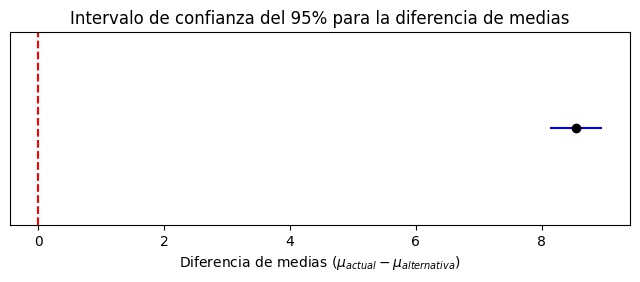

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 2.5))
plt.hlines(y=0, xmin=L_ind, xmax=U_ind, color='blue')
plt.plot(diff, 0, 'o', color='black')
plt.axvline(x=0, linestyle='--', color='red')
plt.yticks([])
plt.xlabel(r"Diferencia de medias $(\mu_{actual} - \mu_{alternativa})$")
plt.title("Intervalo de confianza del 95% para la diferencia de medias")

plt.show()

## 1.5.2 Análisis mediante pruebas pareadas
Se analiza ahora el caso en el que las observaciones de ambas alternactivas están emparejadas y la comparación se realiza sobre la variable diferencia

$$
D_r = W_r^0 - W_r^1
$$

En el contexto de pruebas pareadas, es fundamental que las observaciones de ambas alternativas se generen utilizando la misma secuencia de números aleatorios, con el fin de inducir correlación entre las réplicas correspondientes. Esto permite que las diferencias observadas reflejen principalmente el efecto de las alternativas, reduciendo la influencia del ruido aleatorio.


## Paso 1: Datos

In [6]:
np.random.seed(42)

# Datos base (réplicas preliminares)
w_actual_base = np.array([
    12.66473282,
    7.843314626,
    9.21198858,
    8.438766978,
    12.35851599
])

w_alt_base = np.array([
    1.554471186,
    1.453586058,
    1.346113122,
    1.5570207,
    1.497546971
])

# Estimación de parámetros
media_actual = w_actual_base.mean()
media_alt = w_alt_base.mean()

std_actual = w_actual_base.std(ddof=1)
std_alt = w_alt_base.std(ddof=1)

n = 100
#generación de numeros aleatorios correlacionados
z = np.random.normal(0, 1, n)

# Generación de réplicas correlacionadas
w_actual = media_actual + std_actual * z
w_alt = media_alt + std_alt * z

w_actual, w_alt

(array([11.222989  ,  9.79183513, 11.56326444, 13.53616305,  9.57571438,
         9.57575139, 13.66279169, 11.83315584,  9.04533328, 11.32631931,
         9.05898423,  9.05377316, 10.64881339,  5.79119399,  6.21573689,
         8.83614525,  7.82068214, 10.81173395,  8.05690276,  6.92032603,
        13.40683399,  9.59459515, 10.25566306,  6.89227788,  8.87650021,
        10.35346802,  7.50928301, 10.95023532,  8.74970703,  9.44602631,
         8.74730008, 14.27824337, 10.07304292,  7.71952924, 11.95736659,
         7.35185058, 10.57421354,  5.6866376 ,  7.10991562, 10.54716187,
        11.76786563, 10.48970427,  9.84280852,  9.42481759,  6.77107914,
         8.48103423,  9.06524754, 12.48607151, 10.87793203,  6.12981443,
        10.83390437,  9.23554145,  8.57777497, 11.4820978 , 12.42719453,
        12.20244075,  8.21198324,  9.40654175, 10.85008589, 12.30220798,
         9.02347115,  9.68501407,  7.60993734,  7.40737904, 11.93478495,
        13.16024178,  9.94116292, 12.36528855, 10.9

Se sigue el procedimiento enunciado en pasos anteriores para pruebas pareadas

In [7]:

# Diferencias pareadas
d = w_actual - w_alt

R = len(d)

# 1) Promedio de diferencias
dbar = d.mean()

# 2) Desviación estándar de las diferencias
sd = d.std(ddof=1)

# 3) Error estándar
se_d = sd / math.sqrt(R)

# 4) Grados de libertad
df = R - 1

# 5) Valor crítico t
alpha = 0.05
tcrit = stats.t.ppf(1 - alpha/2, df)

# 6) Half-width
hw_par = tcrit * se_d

# 7) Intervalo de confianza
L_par = dbar - hw_par
U_par = dbar + hw_par

dbar
print("El intervalo de confianza IC es:", (L_par, U_par), "con HW:", hw_par)


El intervalo de confianza IC es: (np.float64(8.006274047835731), np.float64(8.787151398887879)) con HW: 0.39043867552607425


El intervalo de confianza del 95% para la media de las diferencias es completamente
positivo y no contiene el valor cero. En consecuencia, se concluye que la alternativa
con lectores automáticos reduce significativamente el tiempo promedio en el sistema
y mejora el desempeño del proceso de migración.

Adicionalmente, se observa que el half-width del intervalo de confianza bajo pruebas pareadas es
menor que en el caso de muestreo independiente, lo que indica una mayor precisión en
la estimación de la diferencia de desempeño.


## 1.5.3  Conclusión general

Tanto bajo muestreo independiente como mediante pruebas pareadas con números
aleatorios comunes, los intervalos de confianza obtenidos no contienen el valor
cero y son completamente positivos. Por lo tanto, se concluye que la alternativa
con lectores automáticos presenta un mejor desempeño que el escenario actual, al
reducir el tiempo promedio en el sistema.


# 2. Control de error tipo I y II en decisiones

En la comparación de sistemas bajo incertidumbre, la decisión estadística se basa en muestras
aleatorias, por lo que siempre existe riesgo de error.

Planteamiento:
- $H_0: \mu_1 - \mu_2 = 0$
- $H_1: \mu_1 - \mu_2 \neq 0$

Regla de decisión utilizada en esta complementaria:
- Rechazar $H_0$ si el intervalo de confianza para $\mu_1 - \mu_2$ **no contiene 0**.
- No rechazar $H_0$ si el intervalo de confianza **contiene 0**.


### 2.1 Error Tipo I y Error Tipo II

**Error Tipo I ($\alpha$):**  
Rechazar $H_0$ cuando $H_0$ es verdadera.

$$
\alpha = P(\text{rechazar } H_0 \mid H_0 \text{ verdadera})
$$

**Error Tipo II ($\beta$):**  
No rechazar $H_0$ cuando $H_0$ es falsa.

$$
\beta = P(\text{no rechazar } H_0 \mid H_0 \text{ falsa})
$$

**Poder estadístico:**
$$
\text{Poder} = 1 - \beta
$$


### 2.2 Estimación empírica de $\alpha$ y $\beta$ (Monte Carlo)

Para mantener coherencia con la sección anterior, se utiliza simulación Monte Carlo
y la misma regla de decisión basada en intervalos de confianza.

- Cuando $H_0$ es verdadera, la proporción de rechazos estima el error Tipo I ($\alpha$).
- Cuando $H_0$ es falsa, la proporción de rechazos estima el poder estadístico,
  y por tanto $\beta = 1 - \text{Poder}$.


### 2.3 Regla de decisión basada en el intervalo de confianza de Welch

En esta complementaria, la decisión estadística se toma usando un **intervalo de confianza bilateral** para la diferencia de medias $(\mu_1 - \mu_2)$ construido con el método de **Welch** (varianzas desconocidas y no necesariamente iguales).

La regla es:

- Se calcula el intervalo de confianza para $(\mu_1 - \mu_2)$.
- **Se rechaza $H_0$** si el intervalo **NO contiene el valor 0**.
- **No se rechaza $H_0$** si el intervalo **sí contiene 0**.


### 2.4 Estimación empírica mediante simulación Monte Carlo

Para estimar empíricamente el **error Tipo I ($\alpha$)** y el **poder estadístico**, se utiliza simulación Monte Carlo.

El procedimiento es:

1. Repetir $N$ experimentos independientes.
2. En cada experimento:
   - Generar dos muestras normales de tamaño $R$:
     - Muestra 1 $\sim \mathcal{N}(\mu_1, \sigma_1)$  
     - Muestra 2 $\sim \mathcal{N}(\mu_2, \sigma_2)$
   - Construir el intervalo de confianza de Welch para $(\mu_1 - \mu_2)$.
   - Aplicar la regla de decisión: rechazar $H_0$ si el intervalo no contiene 0.
3. La proporción de rechazos estimada se calcula como:

$$
\hat{p} = \frac{\#\text{rechazos}}{N}
$$

- Si se simula el caso $\mu_1 = \mu_2$, entonces $\hat{p}$ estima el **error Tipo I ($\alpha$)**.
- Si se simula el caso $\mu_1 \neq \mu_2$, entonces $\hat{p}$ estima el **poder** y se obtiene:

$$
\beta = 1 - \text{poder}
$$




# 3. Evaluación empírica del Error Tipo I (α), Poder Estadístico y Error Tipo II (β)


## 3.1 Contexto del análisis

Se analiza la comparación del **tiempo promedio en el sistema ($W$)** entre dos configuraciones:

- Sistema actual  
- Sistema alternativo  

El objetivo es determinar si existe una diferencia estadísticamente significativa entre ambos desempeños.

Se plantea el contraste de hipótesis:

$$
H_0: \mu_1 = \mu_2
$$

$$
H_1: \mu_1 \neq \mu_2
$$

donde:

- $\mu_1$: tiempo promedio del sistema actual  
- $\mu_2$: tiempo promedio del sistema alternativo  

El procedimiento de decisión se basa en un intervalo de confianza  tipo Welch con nivel de significancia:

$$
\alpha = 0.05
$$

Para evaluar el comportamiento del procedimiento estadístico, se realiza una simulación Monte Carlo.


### 3.1.1 Estimación empírica del Error Tipo I ($\alpha$)

Para estimar el error Tipo I se simula el caso en que la hipótesis nula es verdadera, es decir:

- $\mu_1 = 10$
- $\mu_2 = 10$
- $\sigma_1 = \sigma_2 = 1.5$

Se generan muestras de tamaño:

- $R = 5$ réplicas por experimento  

y se repite el experimento:

- $N = 20000$ veces  

La proporción de rechazos obtenida estima la probabilidad de rechazar $H_0$ cuando esta es verdadera.

En este contexto, el error Tipo I representa la probabilidad de concluir que el sistema alternativo es diferente del actual cuando en realidad no lo es.


In [21]:
import numpy as np
from scipy import stats
import math

# Parámetros
alpha = 0.05
R = 5
N = 20000
mu1 = 10
mu2 = 10
s1 = 1.5
s2 = 1.5
semilla = 1

rng = np.random.default_rng(semilla)

rechazos = 0

for _ in range(N):
    
    # 1) Generar muestras normales independientes
    muestra_1 = rng.normal(mu1, s1, R)
    muestra_2 = rng.normal(mu2, s2, R)

    # 2) Calcular medias y varianzas muestrales
    media_1 = np.mean(muestra_1)
    media_2 = np.mean(muestra_2)
    var_1 = np.var(muestra_1, ddof=1)
    var_2 = np.var(muestra_2, ddof=1)

    # 3) Diferencia de medias
    diferencia = media_1 - media_2

    # 4) Error estándar (Welch)
    error_estandar = math.sqrt(var_1/R + var_2/R)

    # 5) Grados de libertad (Welch–Satterthwaite)
    gl = (var_1/R + var_2/R)**2 / (
        (var_1**2)/(R**2 * (R-1)) +
        (var_2**2)/(R**2 * (R-1))
    )

    # 6) Valor crítico t
    t_critico = stats.t.ppf(1 - alpha/2, math.floor(gl))

    # 7) Intervalo de confianza
    LI = diferencia - t_critico * error_estandar
    LS = diferencia + t_critico * error_estandar

    # 8) Regla de decisión: rechazar si 0 NO está en el intervalo
    if not (LI <= 0 <= LS):
        rechazos += 1

alpha_empirico = rechazos / N
alpha_empirico


0.03955

### 3.1.2 Estimación empírica del Poder y del Error Tipo II ($\beta$)

Ahora se simula un escenario donde existe una diferencia real entre los sistemas:

- $\mu_1 = 10$
- $\mu_2 = 9$
- $\sigma_1 = \sigma_2 = 1.5$

Es decir, el sistema alternativo reduce en 1 unidad el tiempo promedio.

Se mantiene:

- Tamaño de muestra: $R = 5$
- Número de experimentos: $N = 20000$
- Nivel de significancia: $\alpha = 0.05$
- Semilla: 2027

La proporción de rechazos estima el **poder estadístico**, definido como:

$$
\text{Poder} = P(\text{rechazar } H_0 \mid H_1 \text{ verdadera})
$$

Mientras que el error Tipo II es:

$$
\beta = 1 - \text{Poder}
$$

y representa la probabilidad de no detectar una diferencia cuando esta realmente existe.


In [25]:
# Cambiamos solo mu2 (ahora hay diferencia real)
mu1 = 10
mu2 = 9
R = 100
rng = np.random.default_rng(1)

rechazos = 0

for _ in range(N):
    
    muestra_1 = rng.normal(mu1, s1, R)
    muestra_2 = rng.normal(mu2, s2, R)

    media_1 = np.mean(muestra_1)
    media_2 = np.mean(muestra_2)
    var_1 = np.var(muestra_1, ddof=1)
    var_2 = np.var(muestra_2, ddof=1)

    diferencia = media_1 - media_2
    error_estandar = math.sqrt(var_1/R + var_2/R)

    gl = (var_1/R + var_2/R)**2 / (
        (var_1**2)/(R**2 * (R-1)) +
        (var_2**2)/(R**2 * (R-1))
    )

    t_critico = stats.t.ppf(1 - alpha/2, math.floor(gl))

    LI = diferencia - t_critico * error_estandar
    LS = diferencia + t_critico * error_estandar

    if not (LI <= 0 <= LS):
        rechazos += 1

poder_empirico = rechazos / N
beta_empirico = 1 - poder_empirico

poder_empirico, beta_empirico


(0.9971, 0.0029000000000000137)

Aunque el procedimiento computacional es el mismo en ambos casos, la diferencia conceptual radica en el escenario simulado:

- Si se simula μ1 = μ2, la proporción de rechazos estima el error Tipo I.
- Si se simula μ1 ≠ μ2, la proporción de rechazos estima el poder estadístico.

Ambas cantidades se obtienen como una proporción de rechazos, pero bajo condiciones distintas.


## 3.2 Interpretación de los resultados


- El error Tipo I (α) representa la probabilidad de detectar una diferencia cuando en realidad no existe.
- El poder estadístico indica la capacidad del procedimiento para detectar una diferencia real.
- El error Tipo II (β) representa la probabilidad de no detectar una diferencia cuando sí existe.

Con $R = 5$ réplicas, el poder puede ser bajo, lo que implica una alta probabilidad de error Tipo II.

### 3.2.1 Resultados

Se obtuvo:

- Error Tipo I empírico: 0.03955
- Poder estadístico: 0.1314
- Error Tipo II: 0.8687

El error Tipo I (0.03955) está bien controlado pero ligeramente por debajo de α = 0.05, lo cual es típico con muestras pequeñas (R=5).

Sin embargo, el poder estadístico es bajo (13%), lo que implica una alta probabilidad de cometer error Tipo II. Esto ocurre porque el tamaño de muestra es pequeño (R = 5), lo que genera intervalos de confianza amplios y dificulta detectar diferencias reales entre medias. 

A medida que aumenta R, tanto el control de α como el poder estadístico mejoran. Este resultado subraya la importancia crítica de elegir un tamaño de muestra adecuado en el diseño experimental.
